In [14]:
import pandas as pd

# Load dataset
df = pd.read_csv("train_dataset.csv", low_memory=False)

print(df.head())

   nAcid       apol  naAromAtom  nAromBond  nAtom  nHeavyAtom  nH  nC  nN  nO  \
0      0  77.972653          28         29     64          43  21  29   9   1   
1      0  42.898481           6          6     38          21  17  15   2   3   
2      0  45.201481          11         11     39          22  17  16   3   3   
3      0  57.730481          21         24     48          31  17  22   4   2   
4      0  67.645376          11         11     61          29  32  22   2   4   

   ...  AD2D740  AD2D744  AD2D753  AD2D754  AD2D759  AD2D765  AD2D780  \
0  ...        0        0        0        0        0        0        0   
1  ...        0        0        0        0        0        0        0   
2  ...        0        0        0        0        0        0        0   
3  ...        0        0        0        0        0        0        0   
4  ...        0        0        0        0        0        0        0   

   Molecular Weight  Activity_Label  \
0            587.54               0

In [15]:
import numpy as np
import pandas as pd

# Drop non-numeric columns before correlation calculation
df_numeric = df.select_dtypes(include=[np.number])  # Keep only numeric columns

# Compute correlation matrix
correlation_matrix = df_numeric.corr().abs()

# Identify highly correlated features (threshold = 0.9)
upper_triangle = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper_triangle.columns if any(upper_triangle[column] > 0.9)]

# Drop highly correlated features
df = df.drop(columns=to_drop, errors="ignore")

print(f"Removed {len(to_drop)} highly correlated features.")
print(f"Remaining features: {df.shape[1]}")


Removed 668 highly correlated features.
Remaining features: 3457


/opt/conda/envs/openmm-env/lib/python3.13/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


Top 20 features by Fisher Weight:
 AATSC6c         141.572238
AATSC4c         116.222675
JGI6             88.864095
JGI8             81.045150
AATSC7c          69.159663
AATSC0c          66.043532
JGI5             57.143160
ASP-7            51.862543
AATSC8c          43.154720
JGI2             30.217931
ETA_dAlpha_B     26.357020
JGI4             26.252213
JGI7             25.477667
AATSC6e          24.336480
JGI9             21.994881
ETA_EtaP_B       21.599191
ASP-3            20.867556
VE2_Dzv          19.562612
ASP-2            19.520203
AATSC1c          19.102561
dtype: float64


/tmp/ipykernel_41834/1161880113.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fw_ranked.values[:20], y=fw_ranked.index[:20], palette="viridis")  # Top 20 features


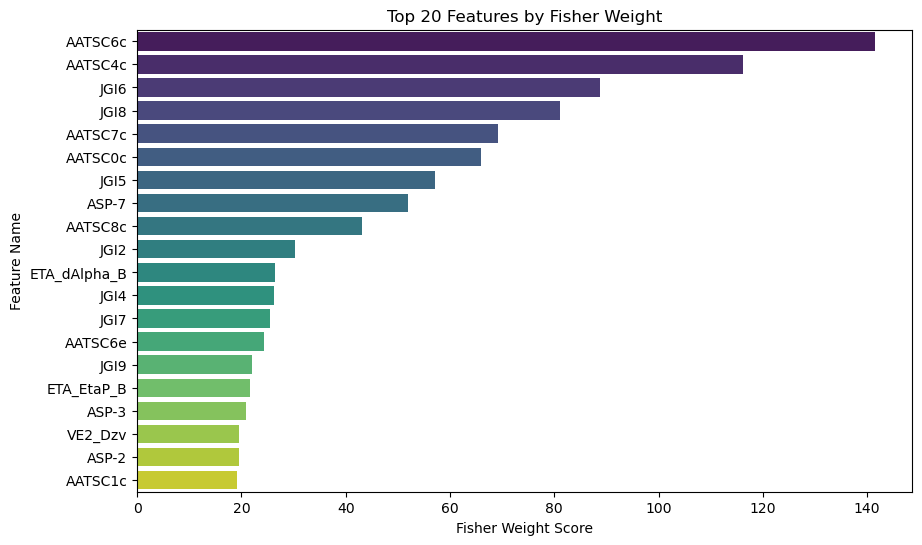

<Figure size 640x480 with 0 Axes>

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway
from sklearn.preprocessing import MinMaxScaler

def fisher_weight(X, y):
    """
    Compute Fisher Weights for each feature.

    Parameters:
    - X: DataFrame of features (only numeric values)
    - y: Target variable (binary classification)

    Returns:
    - A sorted Pandas Series with feature names as index and FW scores as values.
    """
    fw_scores = {}

    # Iterate over each feature column
    for feature in X.columns:
        # Get values for each class
        class_values = [X[feature][y == cls] for cls in np.unique(y)]

        # Fisher Weight formula: (mean difference squared) / (sum of variances)
        if len(class_values) == 2:  # Ensure only two classes
            mean_diff = abs(np.mean(class_values[0]) - np.mean(class_values[1]))
            variance_sum = np.var(class_values[0]) + np.var(class_values[1])

            fw_scores[feature] = mean_diff / variance_sum if variance_sum != 0 else 0
        else:
            fw_scores[feature] = 0  # If more than two classes, set score to 0

    # Convert to Pandas Series & sort by importance
    return pd.Series(fw_scores).sort_values(ascending=False)

# Ensure correct feature & target selection
X = df.select_dtypes(include=[np.number]).drop(columns=["Name", "Smiles"], errors="ignore")
y = df["Activity_Label"]  # Change to the correct column name

# Compute Fisher Weights
fw_ranked = fisher_weight(X, y)

# Display top features
print("Top 20 features by Fisher Weight:\n", fw_ranked.head(20))

# Save results to CSV
fw_ranked.to_csv("feature_importance_fw_ranking.csv")

# Plot Fisher Weight Importance
plt.figure(figsize=(10, 6))
sns.barplot(x=fw_ranked.values[:20], y=fw_ranked.index[:20], palette="viridis")  # Top 20 features
plt.xlabel("Fisher Weight Score")
plt.ylabel("Feature Name")
plt.title("Top 20 Features by Fisher Weight")
plt.show()

plt.savefig("FW_Feature_Importance.png", dpi=300, bbox_inches="tight")  
plt.show()

In [17]:
import numpy as np

# Check for NaN values
print("NaN values in X:", np.isnan(X).sum().sum())

# Check for infinite values
print("Infinite values in X:", np.isinf(X).sum().sum())

# Check for extremely large values
print("Max value in X:", np.max(X.to_numpy()))
print("Min value in X:", np.min(X.to_numpy()))


NaN values in X: 0
Infinite values in X: 140
Max value in X: inf
Min value in X: -1568495812.0


Top 20 Important Features:
         Feature  Importance
153      MATS6s    0.007411
156      GATS1c    0.007033
881       FP550    0.006805
136     AATSC6s    0.006404
124     AATSC6e    0.006191
0         nAcid    0.005488
1516   ExtFP166    0.004855
3306    AD2D339    0.004729
103      ATSC4s    0.004713
269   ETA_Psi_1    0.004536
1027      FP697    0.004536
3351    AD2D495    0.004449
57       ATSC2c    0.004393
139      MATS1c    0.004287
1274      FP946    0.004204
302     MDEC-23    0.004131
2099   ExtFP755    0.003811
50       AATS4s    0.003767
60       ATSC5c    0.003731
226    BCUTc-1h    0.003705


/tmp/ipykernel_41834/322843587.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importance_df["Importance"][:20], y=feature_importance_df["Feature"][:20], palette="viridis")  # Top 20 features


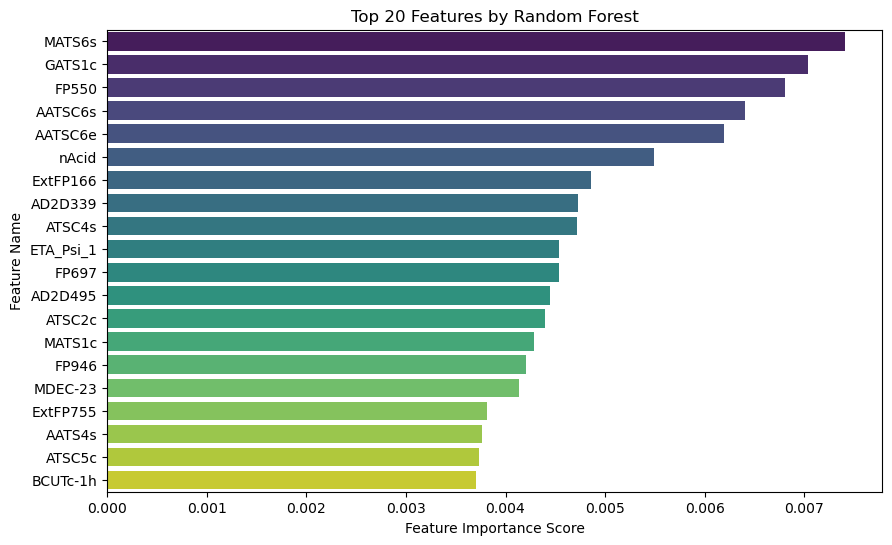

<Figure size 640x480 with 0 Axes>

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

# Separate features and target variable
X = df.drop(columns=["Activity_Label"])  # Features (molecular descriptors)
y = df["Activity_Label"]  # Target labels

# Ensure only numeric features
X = df.drop(columns=["Activity_Label"]).select_dtypes(include=[np.number])

# Replace inf/-inf and very large values with NaN
X = X.replace([np.inf, -np.inf], np.nan)

# Option 1: Replace NaN with column mean
X = X.fillna(X.mean())

# Option 2 (safer): Drop columns with too many NaNs
X = X.dropna(axis=1, how="any")  # if you want to remove problematic features entirely

# Optionally, clip extreme values to avoid overflow during scaling
X = np.clip(X, -1e10, 1e10)

# Scale features (Optional but recommended)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame to retain feature names
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# Train Random Forest for feature selection
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_scaled_df, y)

# Get feature importance scores
feature_importance_df = pd.DataFrame({
    "Feature": X_scaled_df.columns,  
    "Importance": rf.feature_importances_
})

# Sort and display top features
feature_importance_df = feature_importance_df.sort_values(by="Importance", ascending=False)

# Save results to CSV
feature_importance_df.to_csv("feature_importance_rf_ranking.csv")

print("Top 20 Important Features:\n", feature_importance_df.head(20))

# Plot Random Forest Feature Importance
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importance_df["Importance"][:20], y=feature_importance_df["Feature"][:20], palette="viridis")  # Top 20 features
plt.xlabel("Feature Importance Score")
plt.ylabel("Feature Name")
plt.title("Top 20 Features by Random Forest")
plt.show()

plt.savefig("RF_Feature_Importance.png", dpi=300, bbox_inches="tight")  
plt.show()


Weighted Random Forest Feature Importance:
MATS6s       0.006300
MATS1c       0.006056
FP550        0.005362
AATSC6e      0.005224
GATS1c       0.005110
AATSC6s      0.004969
BCUTc-1h     0.004320
nAcid        0.004143
ATSC4e       0.003836
ATSC4s       0.003796
AD2D339      0.003692
AATS4s       0.003658
FP697        0.003562
MATS6m       0.003523
AATS8i       0.003435
AATSC7e      0.003410
JGI5         0.003299
ETA_Psi_1    0.003296
GATS3p       0.003291
AATS0s       0.003235
dtype: float64


/tmp/ipykernel_41834/3830769360.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importance_df["Importance"][:20], y=feature_importance_df["Feature"][:20], palette="viridis")  # Top 20 features


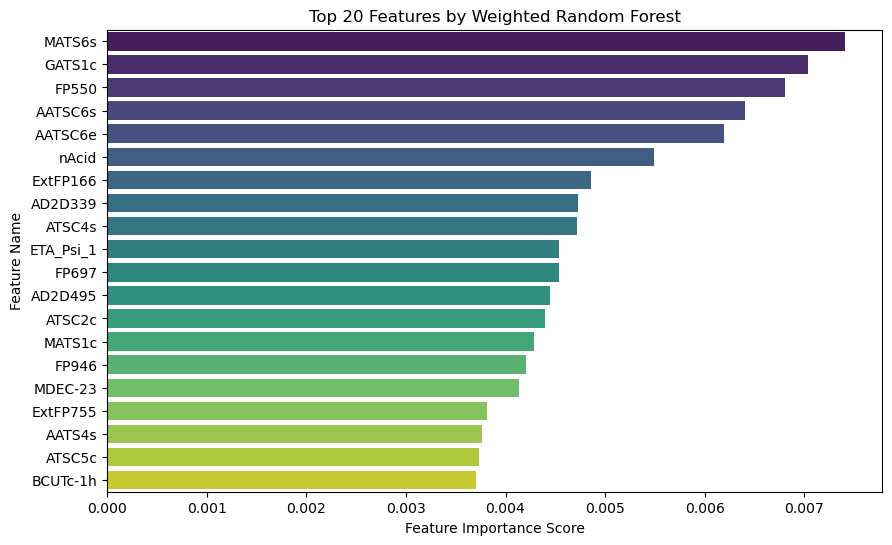

<Figure size 640x480 with 0 Axes>

In [19]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import _tree

# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)


# Train a Random Forest model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

# Define level weights: higher levels get more weight
level_weights = {0: 1.0, 1: 0.5, 2: 0.25, 3: 0.125}  # Default beyond level 3: 0.1

# Function to compute weighted feature importance
def get_feature_importance_wrf(model, X):
    feature_importance = {col: 0 for col in X.columns}

    for tree in model.estimators_:
        tree_ = tree.tree_
        for node in range(tree_.node_count):
            feature_index = tree_.feature[node]
            if feature_index == -2:  # Skip leaf nodes
                continue
            
            feature_name = X.columns[feature_index]
            depth = get_node_depth(tree_, node)
            weight = level_weights.get(depth, 0.1)  # Default weight = 0.1 for deeper levels

            # Accumulate weighted importance
            feature_importance[feature_name] += tree_.impurity[node] * weight

    # Normalize importance values
    total_importance = sum(feature_importance.values())
    feature_importance = {k: v / total_importance for k, v in feature_importance.items()}

    return pd.Series(feature_importance).sort_values(ascending=False)

# Optimized function to compute node depth
def get_node_depth(tree_, node):
    depth = 0
    while node != 0:
        parent = np.where(tree_.children_left == node)[0]
        if parent.size == 0:
            parent = np.where(tree_.children_right == node)[0]
        if parent.size == 0:
            break  # No parent found, avoid infinite loop
        node = parent[0]
        depth += 1
    return depth

# Compute weighted Random Forest importance
wRF_importance = get_feature_importance_wrf(rf, X)

# Print top-ranked features
print("\nWeighted Random Forest Feature Importance:")
print(wRF_importance.head(20))  # Show top 20 features

# Save results to CSV
wRF_importance.to_csv("feature_importance_wRF_ranking.csv")

# Plot Random Forest Feature Importance
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importance_df["Importance"][:20], y=feature_importance_df["Feature"][:20], palette="viridis")  # Top 20 features
plt.xlabel("Feature Importance Score")
plt.ylabel("Feature Name")
plt.title("Top 20 Features by Weighted Random Forest")
plt.show()

plt.savefig("wRF_Feature_Importance.png", dpi=300, bbox_inches="tight")  
plt.show()

/tmp/ipykernel_41834/3116124467.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pca_ranking[:20], y=pca_ranking.index[:20], palette="viridis")


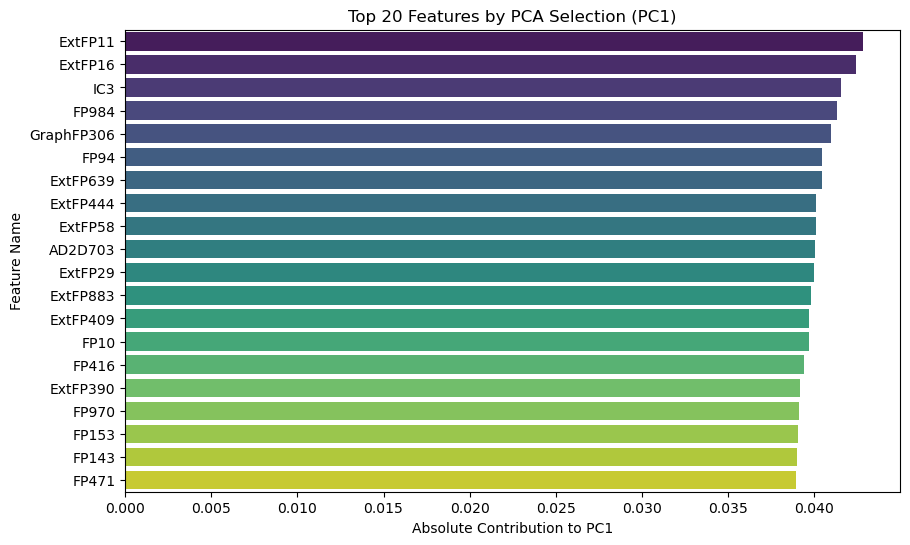

Top 20 PCA Selected Features (PC1 Only):
 ExtFP11       0.042850
ExtFP16       0.042449
IC3           0.041575
FP984         0.041348
GraphFP306    0.040982
FP94          0.040476
ExtFP639      0.040470
ExtFP444      0.040095
ExtFP58       0.040084
AD2D703       0.040073
ExtFP29       0.039986
ExtFP883      0.039845
ExtFP409      0.039699
FP10          0.039696
FP416         0.039391
ExtFP390      0.039178
FP970         0.039097
FP153         0.039043
FP143         0.039014
FP471         0.038939
Name: PC1, dtype: float64


<Figure size 640x480 with 0 Axes>

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Step 2: Standardize the Features (PCA requires mean=0, variance=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 3: Apply PCA (Keep 2 Principal Components)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Step 4: Compute Feature Contributions (PC1)
pca_loadings = pd.DataFrame(pca.components_.T, index=X.columns, columns=['PC1', 'PC2'])
pca_ranking = pca_loadings["PC1"].abs().sort_values(ascending=False)  # Ranking based on PC1

# Step 5: Save PCA Feature Rankings
pca_ranking.to_csv("feature_importance_pca_ranking.csv")

# Step 6: Plot Top 20 PCA Selected Features
plt.figure(figsize=(10, 6))
sns.barplot(x=pca_ranking[:20], y=pca_ranking.index[:20], palette="viridis")
plt.xlabel("Absolute Contribution to PC1")
plt.ylabel("Feature Name")
plt.title("Top 20 Features by PCA Selection (PC1)")
plt.show()

# Step 7: Display Results
print("Top 20 PCA Selected Features (PC1 Only):\n", pca_ranking.head(20))

plt.savefig("PCA_Feature_Importance.png", dpi=300, bbox_inches="tight")  
plt.show()

/tmp/ipykernel_41834/1828757633.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=wpca_ranking[:20], y=wpca_ranking.index[:20], palette="viridis")


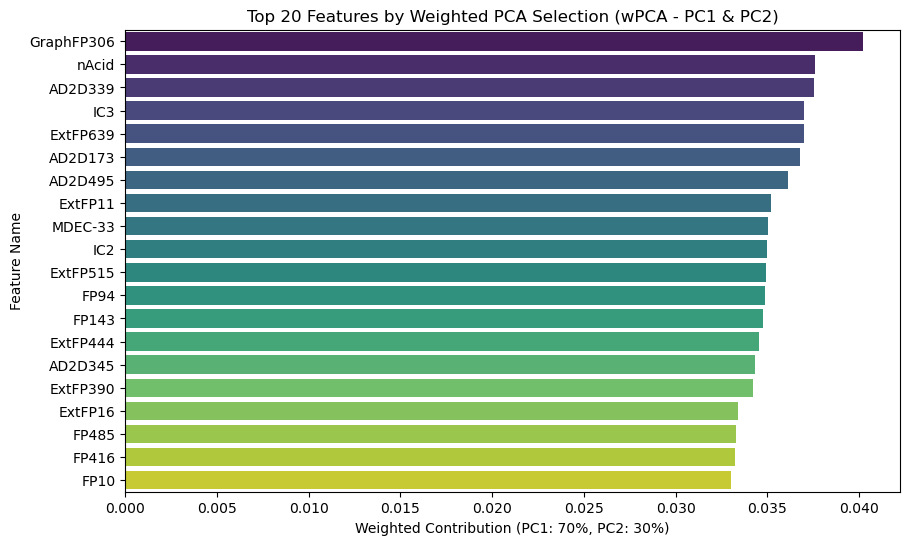

Top 20 Weighted PCA Selected Features (wPCA - PC1 & PC2):
 GraphFP306    0.040218
nAcid         0.037580
AD2D339       0.037530
IC3           0.036971
ExtFP639      0.036968
AD2D173       0.036770
AD2D495       0.036092
ExtFP11       0.035191
MDEC-33       0.035036
IC2           0.034959
ExtFP515      0.034907
FP94          0.034867
FP143         0.034777
ExtFP444      0.034531
AD2D345       0.034335
ExtFP390      0.034225
ExtFP16       0.033420
FP485         0.033283
FP416         0.033243
FP10          0.032999
dtype: float64


<Figure size 640x480 with 0 Axes>

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Step 2: Standardize the Features (PCA requires mean=0, variance=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 3: Apply PCA (Keep 2 Principal Components)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Step 4: Compute Feature Contributions (Weighted PC1 & PC2)
pca_loadings = pd.DataFrame(pca.components_.T, index=X.columns, columns=['PC1', 'PC2'])
wpca_ranking = (pca_loadings["PC1"].abs() * 0.7 + pca_loadings["PC2"].abs() * 0.3).sort_values(ascending=False)

# Step 5: Save wPCA Feature Rankings
wpca_ranking.to_csv("feature_importance_wpca_ranking.csv")

# Step 6: Plot Top 20 wPCA Selected Features
plt.figure(figsize=(10, 6))
sns.barplot(x=wpca_ranking[:20], y=wpca_ranking.index[:20], palette="viridis")
plt.xlabel("Weighted Contribution (PC1: 70%, PC2: 30%)")
plt.ylabel("Feature Name")
plt.title("Top 20 Features by Weighted PCA Selection (wPCA - PC1 & PC2)")
plt.show()

# Step 7: Display Results
print("Top 20 Weighted PCA Selected Features (wPCA - PC1 & PC2):\n", wpca_ranking.head(20))

plt.savefig("wPCA_Feature_Importance.png", dpi=300, bbox_inches="tight")  
plt.show()

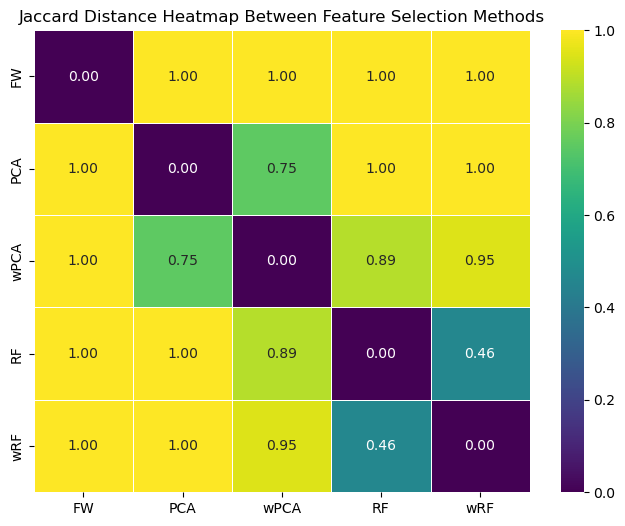

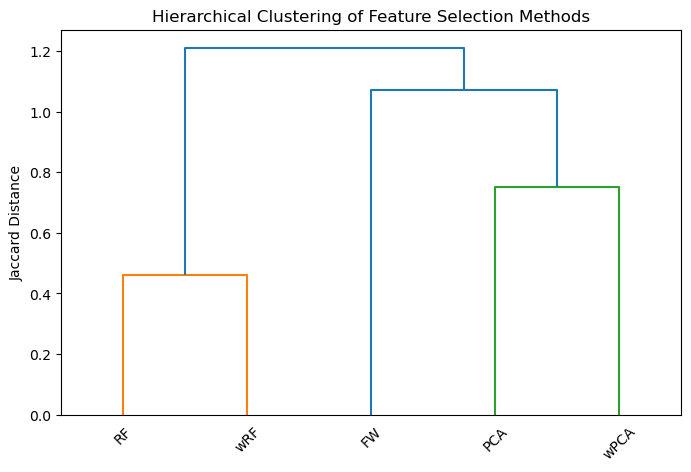

In [22]:
from sklearn.metrics import jaccard_score
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import squareform, pdist
from scipy.cluster.hierarchy import linkage, dendrogram

# Load actual feature selection results (top 10 features from each method)
feature_sets = {
    "FW": set(fw_ranked.index[:10]),  # Fisher Weight
    "PCA": set(pca_ranking.index[:10]),  # PCA Selection
    "wPCA": set(wpca_ranking.index[:10]),  # Weighted PCA
    "RF": set(feature_importance_df["Feature"][:10]),  # Random Forest
    "wRF": set(wRF_importance.index[:10])  # Weighted Random Forest
}

# Get all unique descriptors across methods
all_features = set().union(*feature_sets.values())

# Convert feature sets into binary arrays (1 if feature exists, 0 otherwise)
binary_vectors = {
    method: np.array([1 if feature in selected_features else 0 for feature in all_features])
    for method, selected_features in feature_sets.items()
}

# Compute Jaccard distance matrix
methods = list(feature_sets.keys())
num_methods = len(methods)
jaccard_matrix = np.zeros((num_methods, num_methods))

for i in range(num_methods):
    for j in range(num_methods):
        if i != j:
            jaccard_matrix[i, j] = 1 - jaccard_score(binary_vectors[methods[i]], binary_vectors[methods[j]])

# Convert to Pandas DataFrame for visualization
df_jaccard = pd.DataFrame(jaccard_matrix, index=methods, columns=methods)

# Plot Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df_jaccard, annot=True, cmap="viridis", fmt=".2f", linewidths=0.5)
plt.title("Jaccard Distance Heatmap Between Feature Selection Methods")
plt.savefig("jaccard_distance_heatmap.png", dpi=300)  # Save figure
plt.show()

# Convert the square Jaccard matrix into a condensed form
jaccard_condensed = squareform(jaccard_matrix)

# Perform hierarchical clustering
linkage_matrix = linkage(jaccard_condensed, method='ward')

# Plot dendrogram
plt.figure(figsize=(8, 5))
dendrogram(linkage_matrix, labels=methods, leaf_rotation=45, leaf_font_size=10)
plt.title("Hierarchical Clustering of Feature Selection Methods")
plt.ylabel("Jaccard Distance")
plt.savefig("jaccard_distance_dendrogram.png", dpi=300)  # Save figure
plt.show()


In [24]:
import pandas as pd

# Convert to DataFrame for saving
feature_summary = []
for method, feats in feature_sets.items():
    for f in feats:
        feature_summary.append({"Feature": f, "Method": method})

feature_summary_df = pd.DataFrame(feature_summary)

# Save as CSV
feature_summary_df.to_csv("top_features_summary.csv", index=False)

# Also save the union set for convenience
pd.Series(list(all_features), name="Selected_Features").to_csv("all_top_features.csv", index=False)

print("Saved top_features_summary.csv and all_top_features.csv")

Saved top_features_summary.csv and all_top_features.csv


In [46]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from sklearn.model_selection import cross_val_score

# Load dataset
df = pd.read_csv("train_dataset.csv")

# Keep only the features in your preselected set
X_selected = df[list(all_features)].copy()

# Labels: classification or regression
y = df["pMIC"] if "pMIC" in df.columns else df["Activity_Label"]

# Replace inf with NaN
X_selected = X_selected.replace([np.inf, -np.inf], np.nan)

# Drop columns that are completely NaN
X_selected = X_selected.dropna(axis=1, how="all")

# Fill remaining NaN with column mean
X_selected = X_selected.fillna(X_selected.mean())

# Ensure dtype is float64
X_selected = X_selected.astype(float)

# Initialize classifier
clf = RandomForestClassifier(n_estimators=500, random_state=42)

# Apply RFE (choose number of features to select)
rfe = RFE(estimator=clf, n_features_to_select=20, step=1)
rfe.fit(X_selected, y)

# Get selected features
final_features = X_selected.columns[rfe.support_]
print("RFE-selected features:", final_features.tolist())

# Save RFE-selected features
pd.Series(final_features, name="RFE_Selected_Features").to_csv("rfe_selected_features.csv", index=False)

# Optional: cross-validation to check performance
scores = cross_val_score(clf.fit(X_selected[final_features], y),
                         X_selected[final_features], y, cv=5, scoring="accuracy")
print("CV Accuracy:", scores.mean())


RFE-selected features: ['MATS6s', 'AATSC6e', 'AATSC6c', 'JGI5', 'BCUTc-1h', 'AD2D495', 'ATSC4e', 'ETA_Psi_1', 'GATS1c', 'AATSC4c', 'IC3', 'AATSC8c', 'ASP-7', 'MATS1c', 'IC2', 'JGI2', 'ExtFP166', 'AATSC0c', 'AATSC6s', 'ATSC4s']
CV Accuracy: 0.912628966958339


In [47]:
# Keep only selected features from your dataset
X = X_selected[final_features].copy()

# Labels (choose regression/classification target depending on study)
y = df["pMIC"] if "pMIC" in df.columns else df["Activity_Label"]

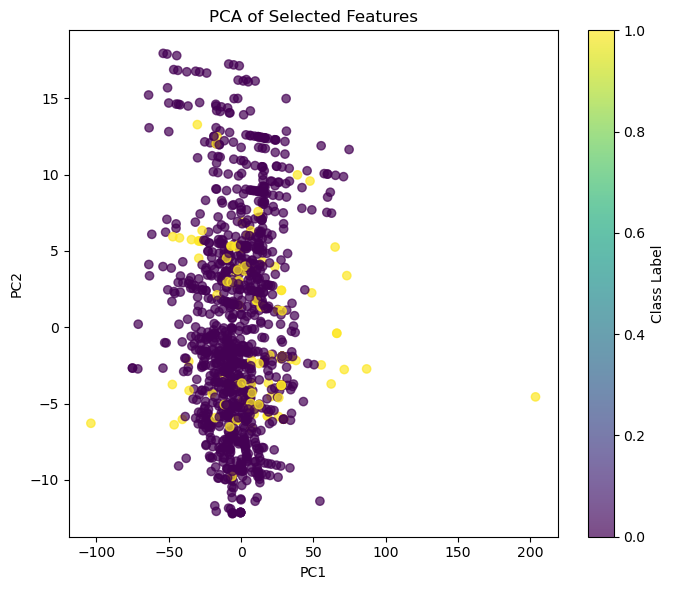

In [48]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_selected)

plt.figure(figsize=(7,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap="viridis", alpha=0.7)
plt.colorbar(label="Activity (pMIC)" if y.dtype.kind in "f" else "Class Label")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Selected Features")
plt.tight_layout()
plt.show()

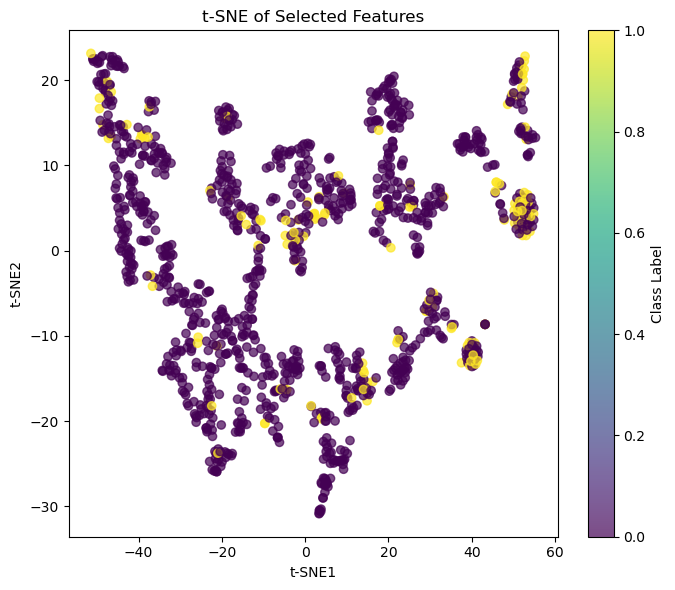

In [49]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_selected)

plt.figure(figsize=(7,6))
plt.scatter(X_tsne[:,0], X_tsne[:,1], c=y, cmap="viridis", alpha=0.7)
plt.colorbar(label="Activity (pMIC)" if y.dtype.kind in "f" else "Class Label")
plt.xlabel("t-SNE1")
plt.ylabel("t-SNE2")
plt.title("t-SNE of Selected Features")
plt.tight_layout()
plt.show()

/opt/conda/envs/openmm-env/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


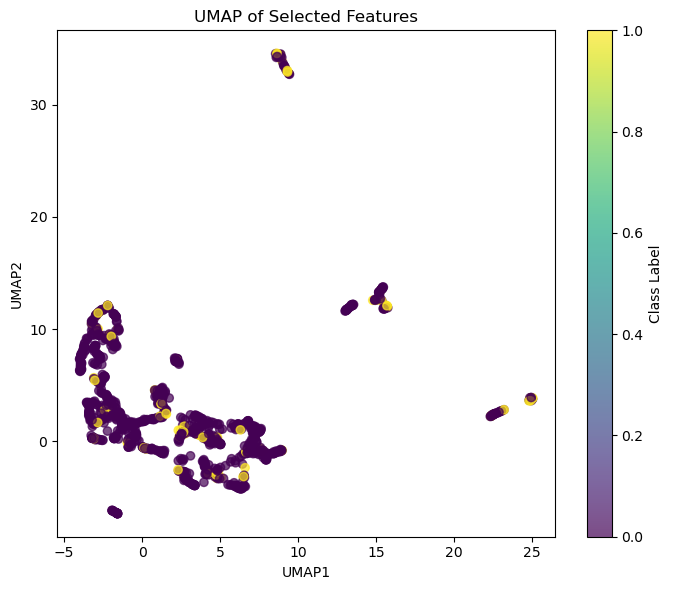

In [50]:
import umap.umap_ as umap

umap_model = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
X_umap = umap_model.fit_transform(X_selected)

plt.figure(figsize=(7,6))
plt.scatter(X_umap[:,0], X_umap[:,1], c=y, cmap="viridis", alpha=0.7)
plt.colorbar(label="Activity (pMIC)" if y.dtype.kind in "f" else "Class Label")
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("UMAP of Selected Features")
plt.tight_layout()
plt.show()

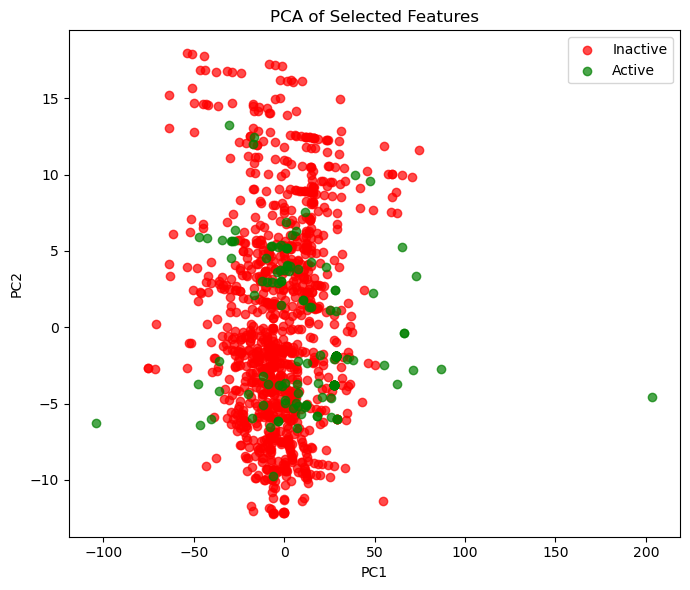

In [51]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_selected)

plt.figure(figsize=(7,6))
for label, color, name in [(0, "red", "Inactive"), (1, "green", "Active")]:
    plt.scatter(
        X_pca[y == label, 0], 
        X_pca[y == label, 1], 
        c=color, label=name, alpha=0.7
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Selected Features")
plt.legend()
plt.tight_layout()
plt.savefig("PCA_classification.png", dpi=1200)
plt.show()

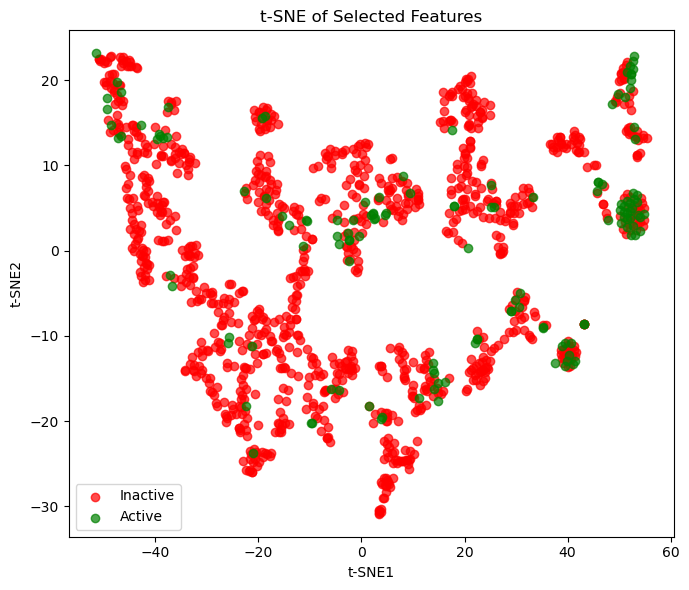

In [52]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_selected)

plt.figure(figsize=(7,6))
for label, color, name in [(0, "red", "Inactive"), (1, "green", "Active")]:
    plt.scatter(
        X_tsne[y == label, 0], 
        X_tsne[y == label, 1], 
        c=color, label=name, alpha=0.7
    )

plt.xlabel("t-SNE1")
plt.ylabel("t-SNE2")
plt.title("t-SNE of Selected Features")
plt.legend()
plt.tight_layout()
plt.savefig("tSNE_classification.png", dpi=1200)
plt.show()

/opt/conda/envs/openmm-env/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


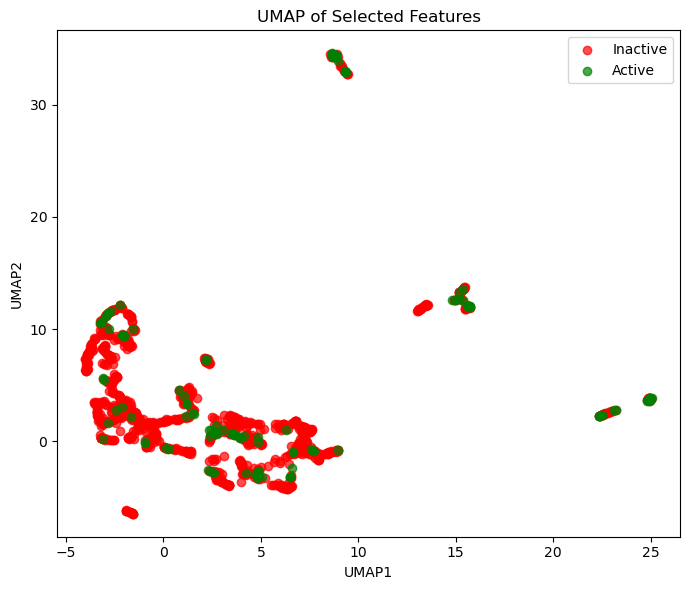

In [53]:
import umap.umap_ as umap

umap_model = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
X_umap = umap_model.fit_transform(X_selected)

plt.figure(figsize=(7,6))
for label, color, name in [(0, "red", "Inactive"), (1, "green", "Active")]:
    plt.scatter(
        X_umap[y == label, 0], 
        X_umap[y == label, 1], 
        c=color, label=name, alpha=0.7
    )

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("UMAP of Selected Features")
plt.legend()
plt.tight_layout()
plt.savefig("UMAP_classification.png", dpi=1200) 
plt.show()